# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [32]:
#Type your code here
# Import library utama
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# KaggleHub untuk load dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

import os

# os.listdir('/kaggle/input/test-file') # This line caused the FileNotFoundError

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [33]:
# Load dataset
import pandas as pd

# Menggunakan dataset Titanic dari URL publik untuk menghindari masalah autentikasi Kaggle
# Ini adalah file train.csv standar dari kompetisi Titanic
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Menampilkan 5 data pertama
print("First 5 records:")
print(df.head())

# Informasi dataset
print("\nInfo dataset:")
df.info()

# Ukuran dataset
print("\nShape dataset:", df.shape)

First 5 records:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

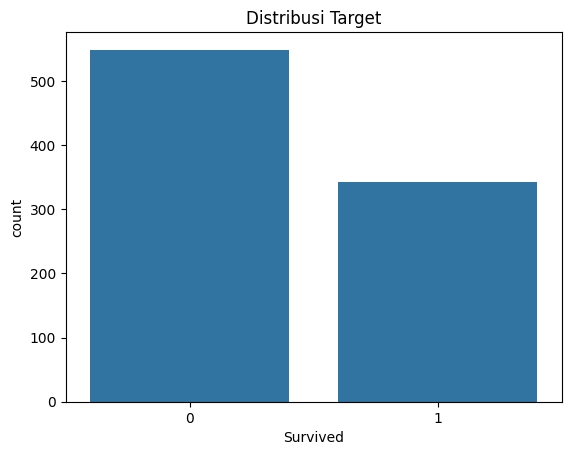

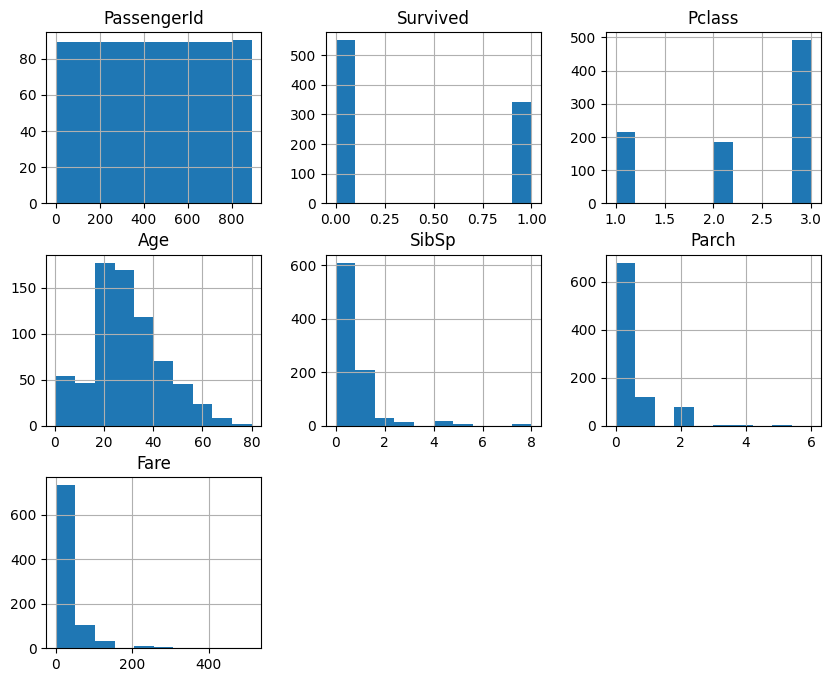

In [34]:
#Type your code here
# Statistik deskriptif
df.describe()

# Cek missing values
df.isnull().sum()
# Visualisasi distribusi target (jika ada kolom target, misalnya 'Survived')
if 'Survived' in df.columns:
    sns.countplot(x='Survived', data=df)
    plt.title("Distribusi Target")
    plt.show()
# Visualisasi distribusi fitur numerik
df.hist(figsize=(10,8))
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [35]:
# Copy dataset agar aman
df_clean = df.copy()

# 🔹 1. Drop kolom tidak penting
df_clean = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 🔹 2. Handle Missing Values
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Fare'].fillna(df_clean['Fare'].median(), inplace=True)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 🔹 3. Hapus duplikat
df_clean = df_clean.drop_duplicates()

# 🔹 4. Encoding
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 🔹 5. Split data
from sklearn.model_selection import train_test_split

X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

/tmp/ipykernel_3009/2207461034.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
/tmp/ipykernel_3009/2207461034.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [36]:
import os

os.makedirs("titanic_preprocessing", exist_ok=True)

train_df = pd.DataFrame(X_train)
train_df['Survived'] = y_train.values

test_df = pd.DataFrame(X_test)
test_df['Survived'] = y_test.values

train_df.to_csv('titanic_preprocessing/train.csv', index=False)
test_df.to_csv('titanic_preprocessing/test.csv', index=False)

print("Dataset berhasil disimpan!")

Dataset berhasil disimpan!
